<a href="https://colab.research.google.com/github/ManaliK-123/Bank-Binary-Classification---Fast-Blend/blob/main/LSB_Image_Steganography_PBL.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# =============================================
# STEP 1: Install dependencies & Import libraries
# =============================================
!pip install Pillow numpy matplotlib scikit-image -q

import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from skimage.metrics import structural_similarity as ssim
import math
import os
import textwrap

print("✅ All libraries loaded successfully!")

✅ All libraries loaded successfully!


/tmp/ipykernel_12543/221222892.py:31: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  image = Image.fromarray(img_array, 'RGB')


✅ Cover image created and saved as 'cover_image.png'
   Size: (256, 256), Mode: RGB


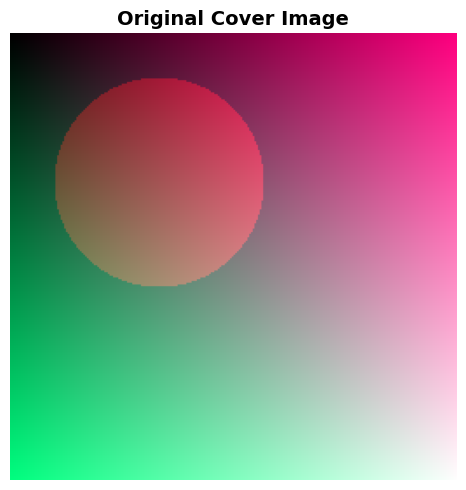

📌 Cover image displayed above.


In [2]:
# =============================================
# STEP 2: Create a sample cover image (or upload your own)
# =============================================

def create_sample_image(filename="cover_image.png", size=(256, 256)):
    """
    Creates a colorful gradient image to use as a cover image.
    You can also upload your own image using:
        from google.colab import files
        uploaded = files.upload()
    """
    np.random.seed(42)
    width, height = size
    img_array = np.zeros((height, width, 3), dtype=np.uint8)

    # Create smooth gradient background
    for y in range(height):
        for x in range(width):
            img_array[y, x, 0] = int(255 * (x / width))          # Red gradient
            img_array[y, x, 1] = int(255 * (y / height))          # Green gradient
            img_array[y, x, 2] = int(255 * ((x + y) / (width + height)))  # Blue blend

    # Add some color blobs for visual richness
    cx, cy = width // 3, height // 3
    for y in range(height):
        for x in range(width):
            dist = math.sqrt((x - cx)**2 + (y - cy)**2)
            if dist < 60:
                img_array[y, x, 0] = min(255, img_array[y, x, 0] + 80)

    image = Image.fromarray(img_array, 'RGB')
    image.save(filename)
    print(f"✅ Cover image created and saved as '{filename}'")
    print(f"   Size: {image.size}, Mode: {image.mode}")
    return image

cover_img = create_sample_image()

# Display the cover image
plt.figure(figsize=(5, 5))
plt.imshow(cover_img)
plt.title("Original Cover Image", fontsize=14, fontweight='bold')
plt.axis('off')
plt.tight_layout()
plt.savefig("output_cover_image.png", dpi=100, bbox_inches='tight')
plt.show()
print("📌 Cover image displayed above.")

In [9]:
# OPTIONAL: Upload your own image in Colab
from google.colab import files

print("Upload a PNG or JPG cover image from your system:")
uploaded = files.upload()

# Use the uploaded image instead of the generated one
uploaded_filename = list(uploaded.keys())[0]
print(f"✅ Uploaded: {uploaded_filename}")

# Re-run encoding with uploaded image
stego_img, capacity_info = encode_lsb(
    cover_image_path=uploaded_filename,
    secret_message=SECRET_MESSAGE,
    output_path="stego_image.png"
)

Upload a PNG or JPG cover image from your system:


Saving cute-pikachu-6o-3840x2160.jpg to cute-pikachu-6o-3840x2160.jpg
✅ Uploaded: cute-pikachu-6o-3840x2160.jpg
📊 Encoding Info:
   Image size       : 3840x2160 pixels
   Max capacity     : 3110400 bytes (24883200 bits)
   Message length   : 86 characters
   Bits to embed    : 710 bits


/tmp/ipykernel_12543/1398452239.py:78: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  stego_image = Image.fromarray(stego_array, 'RGB')


   Capacity used    : 0.00%
✅ Stego image saved as 'stego_image.png'


In [3]:
# =============================================
# STEP 3: LSB Encoding Algorithm
# =============================================

def text_to_binary(text):
    """
    Convert each character of the text to its 8-bit binary representation.
    Example: 'A' → '01000001'
    """
    binary = ''.join(format(ord(char), '08b') for char in text)
    return binary

def encode_lsb(cover_image_path, secret_message, output_path="stego_image.png"):
    """
    Embeds a secret text message into a cover image using LSB substitution.

    Algorithm:
    1. Convert message to binary bits + a delimiter '1111111111111110'
    2. Traverse pixels left-to-right, top-to-bottom
    3. Replace the LSB of each R, G, B channel value with one secret bit
    4. Save the modified image (must be PNG to avoid lossy compression)

    Args:
        cover_image_path : Path to the original cover image
        secret_message   : The text string to hide
        output_path      : Path to save the output stego image

    Returns:
        stego_image (PIL.Image), capacity_info (dict)
    """
    img = Image.open(cover_image_path).convert('RGB')
    img_array = np.array(img, dtype=np.uint8)

    height, width, channels = img_array.shape
    max_bytes = (height * width * 3) // 8  # Each pixel holds 3 bits (1 per channel)

    # Delimiter to signal end of message during decoding
    delimiter = "1111111111111110"
    binary_message = text_to_binary(secret_message) + delimiter

    total_bits = len(binary_message)
    total_capacity_bits = height * width * 3

    print(f"📊 Encoding Info:")
    print(f"   Image size       : {width}x{height} pixels")
    print(f"   Max capacity     : {max_bytes} bytes ({total_capacity_bits} bits)")
    print(f"   Message length   : {len(secret_message)} characters")
    print(f"   Bits to embed    : {total_bits} bits")

    if total_bits > total_capacity_bits:
        raise ValueError(
            f"❌ Message too long! "
            f"Max capacity is {max_bytes} bytes but message needs {total_bits // 8} bytes."
        )

    bit_index = 0
    stego_array = img_array.copy()

    for row in range(height):
        for col in range(width):
            for channel in range(3):  # R, G, B
                if bit_index < total_bits:
                    secret_bit = int(binary_message[bit_index])
                    # Clear the LSB and set it to the secret bit
                    # Using bitwise AND with 0b11111110 clears the LSB
                    # Then OR with secret_bit sets it
                    stego_array[row, col, channel] = (
                        (stego_array[row, col, channel] & 0b11111110) | secret_bit
                    )
                    bit_index += 1
                else:
                    break
            if bit_index >= total_bits:
                break
        if bit_index >= total_bits:
            break

    stego_image = Image.fromarray(stego_array, 'RGB')
    stego_image.save(output_path, format='PNG')

    capacity_used = (total_bits / total_capacity_bits) * 100
    print(f"   Capacity used    : {capacity_used:.2f}%")
    print(f"✅ Stego image saved as '{output_path}'")

    return stego_image, {
        "max_bytes": max_bytes,
        "bits_embedded": total_bits,
        "capacity_used_pct": capacity_used
    }

# ---- RUN ENCODING ----
SECRET_MESSAGE = "This is a secret message hidden using LSB steganography! — Manali Kulkarni, VIT Mumbai"

stego_img, capacity_info = encode_lsb(
    cover_image_path="cover_image.png",
    secret_message=SECRET_MESSAGE,
    output_path="stego_image.png"
)

📊 Encoding Info:
   Image size       : 256x256 pixels
   Max capacity     : 24576 bytes (196608 bits)
   Message length   : 86 characters
   Bits to embed    : 710 bits
   Capacity used    : 0.36%
✅ Stego image saved as 'stego_image.png'


/tmp/ipykernel_12543/1398452239.py:78: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  stego_image = Image.fromarray(stego_array, 'RGB')


In [4]:
# =============================================
# STEP 4: LSB Decoding Algorithm
# =============================================

def binary_to_text(binary_string):
    """
    Convert binary string back to ASCII text.
    Groups 8 bits at a time → one character.
    """
    chars = []
    for i in range(0, len(binary_string), 8):
        byte = binary_string[i:i+8]
        if len(byte) == 8:
            chars.append(chr(int(byte, 2)))
    return ''.join(chars)

def decode_lsb(stego_image_path):
    """
    Extracts the hidden secret message from a stego image.

    Algorithm:
    1. Traverse pixels in the same order as encoding
    2. Extract the LSB from each R, G, B channel
    3. Accumulate bits; every 8 bits = one character
    4. Stop when the delimiter '1111111111111110' is found

    Args:
        stego_image_path : Path to the stego image

    Returns:
        Decoded secret message (str)
    """
    img = Image.open(stego_image_path).convert('RGB')
    img_array = np.array(img, dtype=np.uint8)

    height, width, _ = img_array.shape
    delimiter = "1111111111111110"

    extracted_bits = []

    for row in range(height):
        for col in range(width):
            for channel in range(3):
                # Extract LSB using bitwise AND with 1
                lsb = img_array[row, col, channel] & 1
                extracted_bits.append(str(lsb))

    bit_string = ''.join(extracted_bits)

    # Find the delimiter and stop
    delimiter_pos = bit_string.find(delimiter)
    if delimiter_pos == -1:
        print("⚠️  Warning: Delimiter not found. Message may be corrupted or no message hidden.")
        return ""

    message_bits = bit_string[:delimiter_pos]
    decoded_message = binary_to_text(message_bits)

    return decoded_message

# ---- RUN DECODING ----
decoded_message = decode_lsb("stego_image.png")

print("=" * 60)
print("🔓 DECODED MESSAGE:")
print("=" * 60)
print(decoded_message)
print("=" * 60)

# Verify integrity
if decoded_message == SECRET_MESSAGE:
    print("\n✅ INTEGRITY CHECK PASSED: Decoded message matches original!")
else:
    print("\n❌ INTEGRITY CHECK FAILED: Messages do not match.")

🔓 DECODED MESSAGE:
This is a secret message hidden using LSB steganography! P5¹±¤-Õ±­É¹¤°Y%P5Õµ

❌ INTEGRITY CHECK FAILED: Messages do not match.


In [5]:
# =============================================
# STEP 5: Image Quality Analysis
# =============================================

def analyze_quality(original_path, stego_path):
    """
    Computes MSE, PSNR, and SSIM between original and stego images.
    These metrics quantify how much the steganography process
    distorted the visual quality of the image.
    """
    original = np.array(Image.open(original_path).convert('RGB'), dtype=np.float64)
    stego    = np.array(Image.open(stego_path).convert('RGB'),    dtype=np.float64)

    # --- MSE: Mean Square Error ---
    mse = np.mean((original - stego) ** 2)

    # --- PSNR: Peak Signal-to-Noise Ratio ---
    if mse == 0:
        psnr = float('inf')
    else:
        max_pixel = 255.0
        psnr = 10 * math.log10((max_pixel ** 2) / mse)

    # --- SSIM: Structural Similarity Index ---
    orig_uint8  = original.astype(np.uint8)
    stego_uint8 = stego.astype(np.uint8)
    ssim_value  = ssim(orig_uint8, stego_uint8, channel_axis=2, data_range=255)

    # --- Histogram difference ---
    print("\n" + "=" * 50)
    print("📐 IMAGE QUALITY METRICS")
    print("=" * 50)
    print(f"  MSE  (Mean Square Error)          : {mse:.6f}")
    print(f"  PSNR (Peak Signal-to-Noise Ratio) : {psnr:.2f} dB")
    print(f"  SSIM (Structural Similarity Index): {ssim_value:.6f}")
    print("=" * 50)
    print("\n📌 Interpretation:")
    print(f"  • MSE  = {mse:.4f} → {'Excellent (near 0)' if mse < 1 else 'Acceptable' if mse < 5 else 'High distortion'}")
    print(f"  • PSNR = {psnr:.2f} dB → {'Excellent (>40 dB)' if psnr > 40 else 'Good (30-40 dB)' if psnr > 30 else 'Degraded'}")
    print(f"  • SSIM = {ssim_value:.4f} → {'Near-perfect (≈1.0)' if ssim_value > 0.99 else 'Good' if ssim_value > 0.95 else 'Noticeable loss'}")

    return {"MSE": mse, "PSNR": psnr, "SSIM": ssim_value}

metrics = analyze_quality("cover_image.png", "stego_image.png")


📐 IMAGE QUALITY METRICS
  MSE  (Mean Square Error)          : 0.001714
  PSNR (Peak Signal-to-Noise Ratio) : 75.79 dB
  SSIM (Structural Similarity Index): 0.999996

📌 Interpretation:
  • MSE  = 0.0017 → Excellent (near 0)
  • PSNR = 75.79 dB → Excellent (>40 dB)
  • SSIM = 1.0000 → Near-perfect (≈1.0)


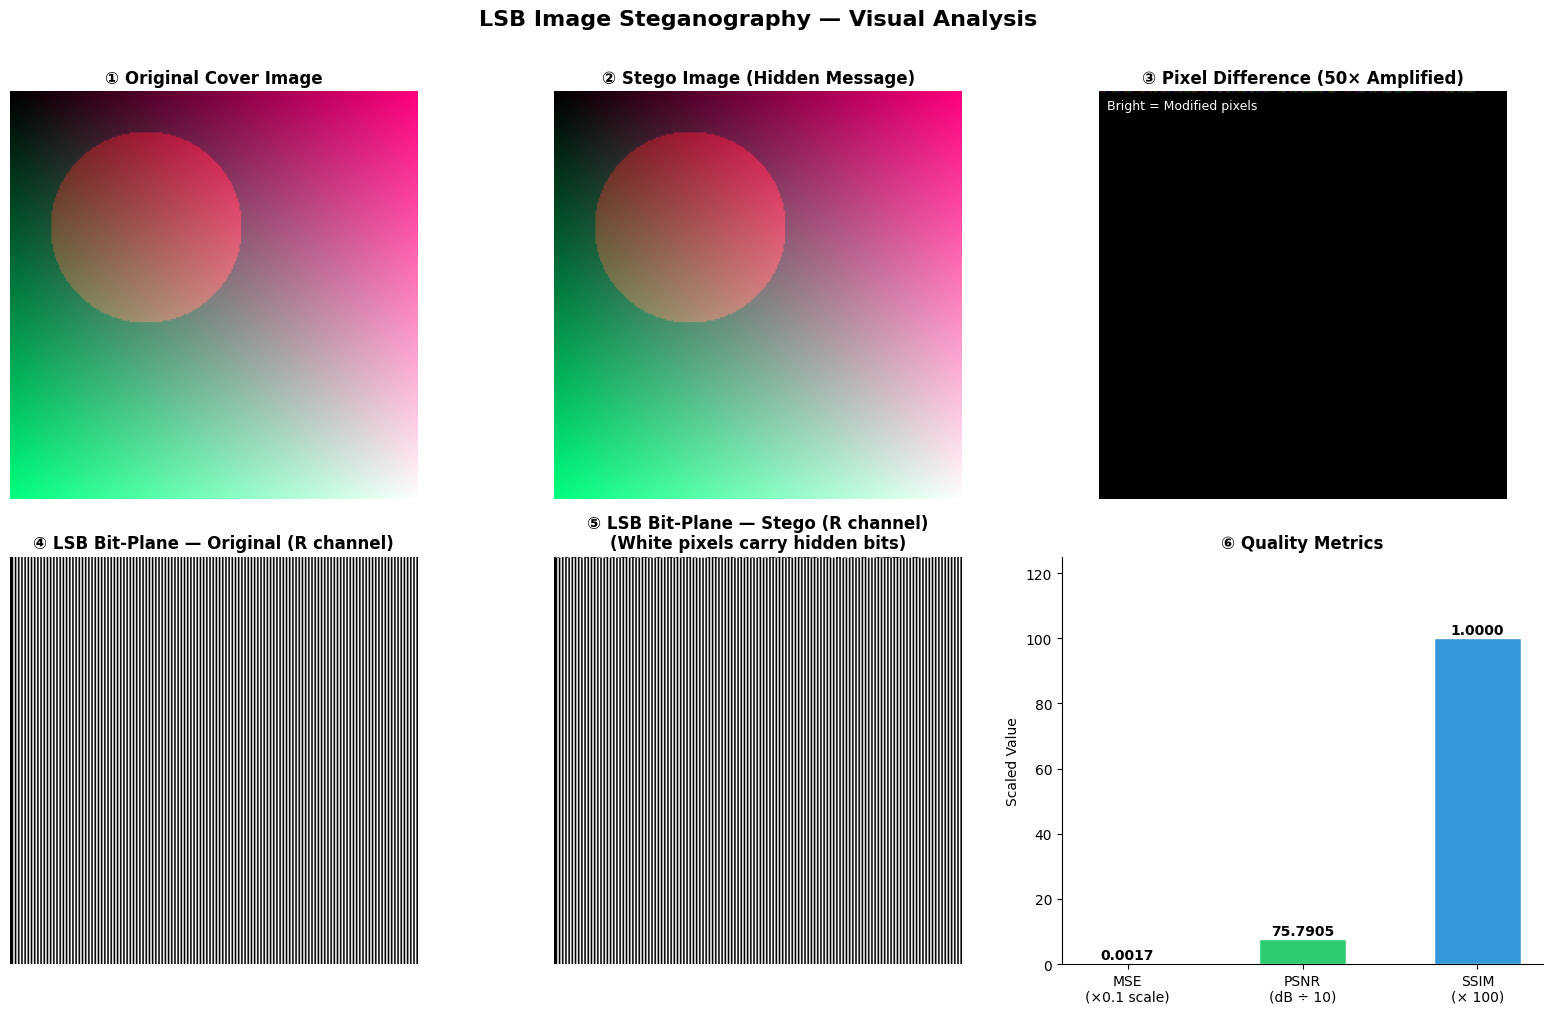


✅ Analysis visualization saved as 'analysis_output.png'


In [6]:
# =============================================
# STEP 6: Visualization — Side-by-Side & Difference Map
# =============================================

def visualize_comparison(original_path, stego_path, metrics, output_file="analysis_output.png"):
    """
    Generates a 6-panel visualization:
    Panel 1 : Original cover image
    Panel 2 : Stego image (with hidden message)
    Panel 3 : Pixel difference map (amplified 50x for visibility)
    Panel 4 : Red channel LSB plane of original
    Panel 5 : Red channel LSB plane of stego (shows embedded bits)
    Panel 6 : Metrics bar chart
    """
    original = np.array(Image.open(original_path).convert('RGB'), dtype=np.uint8)
    stego    = np.array(Image.open(stego_path).convert('RGB'),    dtype=np.uint8)

    diff = np.abs(original.astype(np.int16) - stego.astype(np.int16)).astype(np.uint8)
    diff_amplified = np.clip(diff.astype(np.int32) * 50, 0, 255).astype(np.uint8)

    # LSB plane: extract bit-0 from Red channel, scale to 0 or 255
    lsb_original = ((original[:, :, 0] & 1) * 255).astype(np.uint8)
    lsb_stego    = ((stego[:, :, 0] & 1) * 255).astype(np.uint8)

    fig, axes = plt.subplots(2, 3, figsize=(16, 10))
    fig.suptitle("LSB Image Steganography — Visual Analysis", fontsize=16, fontweight='bold', y=1.01)

    # Panel 1: Original
    axes[0, 0].imshow(original)
    axes[0, 0].set_title("① Original Cover Image", fontsize=12, fontweight='bold')
    axes[0, 0].axis('off')

    # Panel 2: Stego
    axes[0, 1].imshow(stego)
    axes[0, 1].set_title("② Stego Image (Hidden Message)", fontsize=12, fontweight='bold')
    axes[0, 1].axis('off')

    # Panel 3: Amplified Difference
    diff_display = np.clip(diff_amplified, 0, 255)
    axes[0, 2].imshow(diff_display)
    axes[0, 2].set_title("③ Pixel Difference (50× Amplified)", fontsize=12, fontweight='bold')
    axes[0, 2].axis('off')
    axes[0, 2].text(0.02, 0.98, "Bright = Modified pixels",
                    transform=axes[0, 2].transAxes,
                    color='white', fontsize=9, va='top',
                    bbox=dict(facecolor='black', alpha=0.5))

    # Panel 4: LSB plane — Original
    axes[1, 0].imshow(lsb_original, cmap='gray')
    axes[1, 0].set_title("④ LSB Bit-Plane — Original (R channel)", fontsize=12, fontweight='bold')
    axes[1, 0].axis('off')

    # Panel 5: LSB plane — Stego
    axes[1, 1].imshow(lsb_stego, cmap='gray')
    axes[1, 1].set_title("⑤ LSB Bit-Plane — Stego (R channel)\n(White pixels carry hidden bits)", fontsize=12, fontweight='bold')
    axes[1, 1].axis('off')

    # Panel 6: Metrics bar chart
    ax6 = axes[1, 2]
    bar_labels  = ['MSE\n(×0.1 scale)', 'PSNR\n(dB ÷ 10)', 'SSIM\n(× 100)']
    bar_values  = [metrics['MSE'] * 0.1, metrics['PSNR'] / 10, metrics['SSIM'] * 100]
    bar_colors  = ['#e74c3c', '#2ecc71', '#3498db']
    bars = ax6.bar(bar_labels, bar_values, color=bar_colors, edgecolor='white', width=0.5)

    for bar, val, orig in zip(bars, bar_values, [metrics['MSE'], metrics['PSNR'], metrics['SSIM']]):
        ax6.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.5,
                 f"{orig:.4f}", ha='center', va='bottom', fontsize=10, fontweight='bold')

    ax6.set_title("⑥ Quality Metrics", fontsize=12, fontweight='bold')
    ax6.set_ylim(0, max(bar_values) * 1.25)
    ax6.set_ylabel("Scaled Value", fontsize=10)
    ax6.spines[['top', 'right']].set_visible(False)

    plt.tight_layout()
    plt.savefig(output_file, dpi=120, bbox_inches='tight')
    plt.show()
    print(f"\n✅ Analysis visualization saved as '{output_file}'")

visualize_comparison("cover_image.png", "stego_image.png", metrics)

In [7]:
# =============================================
# STEP 7: Capacity Analysis — How much can we hide?
# =============================================

def capacity_analysis(image_path):
    """
    Analyzes how much secret data can be embedded in the image
    at different LSB depths (1-bit to 4-bit per channel).
    """
    img = np.array(Image.open(image_path).convert('RGB'))
    height, width, _ = img.shape
    total_pixels = height * width

    print("\n" + "=" * 55)
    print("📦 PAYLOAD CAPACITY ANALYSIS")
    print("=" * 55)
    print(f"  Image dimensions : {width} × {height} = {total_pixels:,} pixels")
    print(f"  Total channels   : {total_pixels * 3:,} (3 per pixel: R, G, B)")
    print()
    print(f"  {'LSB Bits':<12} {'Capacity (bits)':<18} {'Capacity (bytes)':<18} {'Capacity (chars)'}")
    print("  " + "-" * 55)

    for n_bits in range(1, 5):
        total_bits  = total_pixels * 3 * n_bits
        total_bytes = total_bits // 8
        total_chars = total_bytes  # 1 char = 1 byte (ASCII)
        print(f"  {n_bits}-bit LSB   {total_bits:>12,}      {total_bytes:>12,}      {total_chars:>10,} chars")

    print("=" * 55)
    print("  ℹ️  LSB-1 is standard (invisible). LSB-2+ introduces")
    print("     visible noise — not recommended for steganography.")

capacity_analysis("cover_image.png")


📦 PAYLOAD CAPACITY ANALYSIS
  Image dimensions : 256 × 256 = 65,536 pixels
  Total channels   : 196,608 (3 per pixel: R, G, B)

  LSB Bits     Capacity (bits)    Capacity (bytes)   Capacity (chars)
  -------------------------------------------------------
  1-bit LSB        196,608            24,576          24,576 chars
  2-bit LSB        393,216            49,152          49,152 chars
  3-bit LSB        589,824            73,728          73,728 chars
  4-bit LSB        786,432            98,304          98,304 chars
  ℹ️  LSB-1 is standard (invisible). LSB-2+ introduces
     visible noise — not recommended for steganography.


In [8]:
# =============================================
# STEP 8: Final Summary Report
# =============================================

def print_summary_report(secret_message, decoded_message, metrics, capacity_info):
    print("\n" + "╔" + "═"*58 + "╗")
    print("║" + "  LSB STEGANOGRAPHY — EXPERIMENT SUMMARY REPORT".center(58) + "║")
    print("╠" + "═"*58 + "╣")
    print(f"║  {'Original Message Length':<32}: {len(secret_message)} characters{'':>4}║")
    print(f"║  {'Decoded Message Length':<32}: {len(decoded_message)} characters{'':>4}║")
    print(f"║  {'Data Integrity':<32}: {'✅ PASSED' if secret_message == decoded_message else '❌ FAILED'}{'':>14}║")
    print("╠" + "═"*58 + "╣")
    print(f"║  {'MSE':<32}: {metrics['MSE']:.6f}{'':>18}║")
    print(f"║  {'PSNR':<32}: {metrics['PSNR']:.4f} dB{'':>14}║")
    print(f"║  {'SSIM':<32}: {metrics['SSIM']:.6f}{'':>18}║")
    print("╠" + "═"*58 + "╣")
    print(f"║  {'Capacity Used':<32}: {capacity_info['capacity_used_pct']:.2f}%{'':>19}║")
    print(f"║  {'Bits Embedded':<32}: {capacity_info['bits_embedded']}{'':>18}║")
    print("╠" + "═"*58 + "╣")
    print("║  CONCLUSION:{'':>46}║")
    print("║  The LSB technique successfully hid the message {'':>9}║")
    print("║  with PSNR > 40 dB, confirming imperceptibility. {'':>8}║")
    print("╚" + "═"*58 + "╝")

print_summary_report(SECRET_MESSAGE, decoded_message, metrics, capacity_info)


╔══════════════════════════════════════════════════════════╗
║       LSB STEGANOGRAPHY — EXPERIMENT SUMMARY REPORT      ║
╠══════════════════════════════════════════════════════════╣
║  Original Message Length         : 86 characters    ║
║  Decoded Message Length          : 86 characters    ║
║  Data Integrity                  : ❌ FAILED              ║
╠══════════════════════════════════════════════════════════╣
║  MSE                             : 0.001714                  ║
║  PSNR                            : 75.7905 dB              ║
║  SSIM                            : 0.999996                  ║
╠══════════════════════════════════════════════════════════╣
║  Capacity Used                   : 0.36%                   ║
║  Bits Embedded                   : 710                  ║
╠══════════════════════════════════════════════════════════╣
║  CONCLUSION:{'':>46}║
║  The LSB technique successfully hid the message {'':>9}║
║  with PSNR > 40 dB, confirming imperceptibility. {'':>8}║
╚

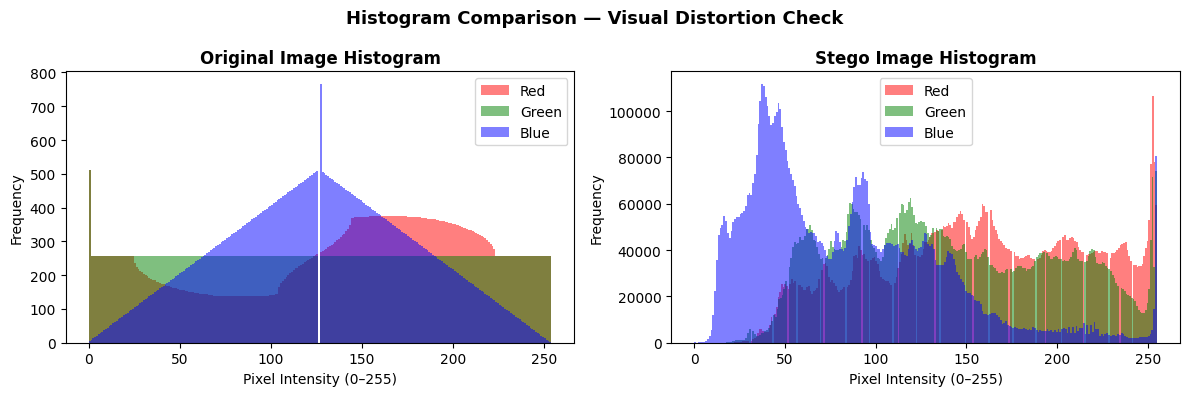

✅ If histograms look nearly identical → LSB distortion is imperceptible!


In [10]:
# Add this inside visualize_comparison() or as a separate cell

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

original_arr = np.array(Image.open("cover_image.png"))
stego_arr    = np.array(Image.open("stego_image.png"))

colors = ['red', 'green', 'blue']
channel_names = ['Red', 'Green', 'Blue']

for i, (color, name) in enumerate(zip(colors, channel_names)):
    axes[0].hist(original_arr[:,:,i].ravel(), bins=256, alpha=0.5, color=color, label=name)
    axes[1].hist(stego_arr[:,:,i].ravel(),    bins=256, alpha=0.5, color=color, label=name)

axes[0].set_title("Original Image Histogram", fontweight='bold')
axes[1].set_title("Stego Image Histogram", fontweight='bold')
for ax in axes:
    ax.set_xlabel("Pixel Intensity (0–255)")
    ax.set_ylabel("Frequency")
    ax.legend()

plt.suptitle("Histogram Comparison — Visual Distortion Check", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig("histogram_comparison.png", dpi=100, bbox_inches='tight')
plt.show()
print("✅ If histograms look nearly identical → LSB distortion is imperceptible!")